In [1]:
# =============================================================================
# CELL 1: IMPORTS
# =============================================================================

# ── Standard Library ──
import os
import glob
import math
import time
import copy
import random
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# ── Scientific Computing ──
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── PyTorch Core ──
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

# ── PyTorch Data ──
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ── Torchvision ──
from torchvision import transforms
from torchvision.transforms import functional as TF

# ── Sklearn ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc,
)

# ── Augmentation ──
import albumentations as A

print("✅ All libraries imported successfully!")


# =============================================================================
# CELL 2: SEED & DEVICE SETUP
# =============================================================================

SEED = 42

def seed_everything(seed: int = SEED) -> None:
    """Ensure full reproducibility across all random sources."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"🖥️  Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"🔥 GPU    : {torch.cuda.get_device_name(0)}")
    print(f"✅ FP16   : Supported")
else:
    print("⚠️  No GPU detected — training will be slow on CPU.")


✅ All libraries imported successfully!
🖥️  Device : cuda
🔥 GPU    : Tesla T4
✅ FP16   : Supported


In [2]:
!pip install thop 


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 1 — IMPORTS · CONFIG · AUGMENTATIONS · DATASET · LOADERS            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# 1.1  DATASET CONFIG
# ═══════════════════════════════════════════════════════════════════════════════

class Config:
    DATASET_ROOT = '/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data'

    CLASSES = [
        "adenocarcinoma", 
        "large.cell.carcinoma", 
        "normal", 
        "squamous.cell.carcinoma"
    ]
    
    CLASS_TO_IDX = {cls_name: idx for idx, cls_name in enumerate(CLASSES)}
    IDX_TO_CLASS = {idx: cls_name for idx, cls_name in enumerate(CLASSES)}
    NUM_CLASSES  = 4

    IMG_SIZE   = 224
    BATCH_SIZE = 64
    SEED       = 42

    # ── Augmentation — Geometric ──────────────────────────────────────────────
    HFLIP_PROB     = 0.5    
    ROTATE_LIMIT   = 15     
    ROTATE_PROB    = 0.5
    ELASTIC_ALPHA  = 120    
    ELASTIC_SIGMA  = 6      
    ELASTIC_PROB   = 0.3

    # ── Augmentation — Photometric ────────────────────────────────────────────
    CLAHE_CLIP        = 2.0     
    CLAHE_PROB        = 0.3
    BRIGHTNESS_LIMIT  = 0.1     
    CONTRAST_LIMIT    = 0.1     
    BC_PROB           = 0.3
    NOISE_VAR         = (10, 50)
    NOISE_PROB        = 0.2

cfg = Config()
print("✅ Config ready")

# ═══════════════════════════════════════════════════════════════════════════════
# 1.2  AUGMENTATION PIPELINE (Albumentations)
# ═══════════════════════════════════════════════════════════════════════════════

def get_train_transform(config: Config = cfg) -> A.Compose:
    return A.Compose([
        A.Resize(config.IMG_SIZE, config.IMG_SIZE),
        A.HorizontalFlip(p=config.HFLIP_PROB),
        A.Rotate(limit=config.ROTATE_LIMIT, p=config.ROTATE_PROB, border_mode=0),
        A.ElasticTransform(
            alpha=config.ELASTIC_ALPHA, sigma=config.ELASTIC_SIGMA,
            p=config.ELASTIC_PROB, border_mode=0),
        A.CLAHE(clip_limit=config.CLAHE_CLIP, tile_grid_size=(8, 8), p=config.CLAHE_PROB),
        A.RandomBrightnessContrast(
            brightness_limit=config.BRIGHTNESS_LIMIT,
            contrast_limit=config.CONTRAST_LIMIT,
            p=config.BC_PROB),
        A.GaussNoise(var_limit=config.NOISE_VAR, p=config.NOISE_PROB),
    ])

def get_val_transform(config: Config = cfg) -> A.Compose:
    return A.Compose([A.Resize(config.IMG_SIZE, config.IMG_SIZE)])

train_transform = get_train_transform()
val_transform   = get_val_transform()
print("✅ Augmentation transforms ready")

# ═══════════════════════════════════════════════════════════════════════════════
# 1.3  DATASET CLASS
# ═══════════════════════════════════════════════════════════════════════════════

class CTDataset(Dataset):
    def __init__(self, image_paths: list, labels: list, transform: A.Compose):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Convert to RGB (3 channels)
        img   = np.array(Image.open(self.image_paths[idx]).convert('RGB'))
        
        # Apply albumentations
        img   = self.transform(image=img)['image']
        
        # Normalize to [-1, 1] range and reorder to (C, H, W) for PyTorch
        img   = (img.astype(np.float32) / 255.0) * 2.0 - 1.0   
        img   = torch.FloatTensor(img).permute(2, 0, 1)        
        
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

# ═══════════════════════════════════════════════════════════════════════════════
# 1.4  DATA LOADING & DATALOADER BUILDER
# ═══════════════════════════════════════════════════════════════════════════════

def load_paths_from_split(root_dir: str, split_name: str):
    """Matches folder names by checking if they start with the base class name."""
    _EXT = {'.png', '.jpg', '.jpeg'}
    paths, labels = [], []
    
    split_dir = os.path.join(root_dir, split_name)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"Directory not found: {split_dir}")

    for folder_name in sorted(os.listdir(split_dir)):
        folder_path = os.path.join(split_dir, folder_name)
        if not os.path.isdir(folder_path):
            continue
            
        assigned_class = None
        for base_class in cfg.CLASSES:
            if folder_name.startswith(base_class):
                assigned_class = base_class
                break
                
        if assigned_class is None:
            continue
            
        for fname in sorted(os.listdir(folder_path)):
            if os.path.splitext(fname)[1].lower() in _EXT:
                paths.append(os.path.join(folder_path, fname))
                labels.append(cfg.CLASS_TO_IDX[assigned_class])
                
    return paths, labels

def build_dataloaders():
    print("\n" + "=" * 60)
    print("📊 BUILDING DATALOADERS")
    print("=" * 60)

    train_p, train_l = load_paths_from_split(cfg.DATASET_ROOT, 'train')
    valid_p, valid_l = load_paths_from_split(cfg.DATASET_ROOT, 'valid')
    test_p, test_l   = load_paths_from_split(cfg.DATASET_ROOT, 'test')

    print(f"\n✂️  Split sizes → Train: {len(train_p)} | Val: {len(valid_p)} | Test: {len(test_p)}")
    print(f"Train dist : {dict(Counter(train_l))}")

    train_ds = CTDataset(train_p, train_l, train_transform)
    val_ds   = CTDataset(valid_p, valid_l, val_transform)
    test_ds  = CTDataset(test_p,  test_l,  val_transform)

    _loader_kwargs = dict(num_workers=2, pin_memory=True)
    
    # Simple shuffling without WeightedRandomSampler
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, drop_last=True, **_loader_kwargs)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False, **_loader_kwargs)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False, **_loader_kwargs)

    # Note: class_weights has been removed from the return statement
    return train_loader, val_loader, test_loader, (train_p, train_l)

# ═══════════════════════════════════════════════════════════════════════════════
# 1.5  RUN — BUILD LOADERS & VERIFY
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    # class_weights removed from the unpacking variables
    train_loader, val_loader, test_loader, (train_paths, train_labels) = build_dataloaders()

    batch_imgs, batch_lbls = next(iter(train_loader))
    print("\n" + "=" * 60)
    print("✅ BATCH SANITY CHECK")
    print("=" * 60)
    print(f"  Shape      : {tuple(batch_imgs.shape)} # Expected (Batch, 3, 224, 224)")
    print(f"  Pixel range: [{batch_imgs.min():.2f}, {batch_imgs.max():.2f}]")
    print(f"  Class dist : {dict(Counter(batch_lbls.numpy().tolist()))}")

✅ Config ready
✅ Augmentation transforms ready

📊 BUILDING DATALOADERS

✂️  Split sizes → Train: 613 | Val: 72 | Test: 315
Train dist : {0: 195, 1: 115, 2: 148, 3: 155}

✅ BATCH SANITY CHECK
  Shape      : (64, 3, 224, 224) # Expected (Batch, 3, 224, 224)
  Pixel range: [-1.00, 1.00]
  Class dist : {2: 12, 3: 20, 0: 21, 1: 11}


{'normal': 2, 'adenocarcinoma_left.lower.lobe': 0, 'large.cell.carcinoma_left.hilum': 1, 'squamous.cell.carcinoma_left.hilum': 3}
Image tensor:
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
Image shape: torch.Size([3, 224, 224])
Image datatype: torch.float32


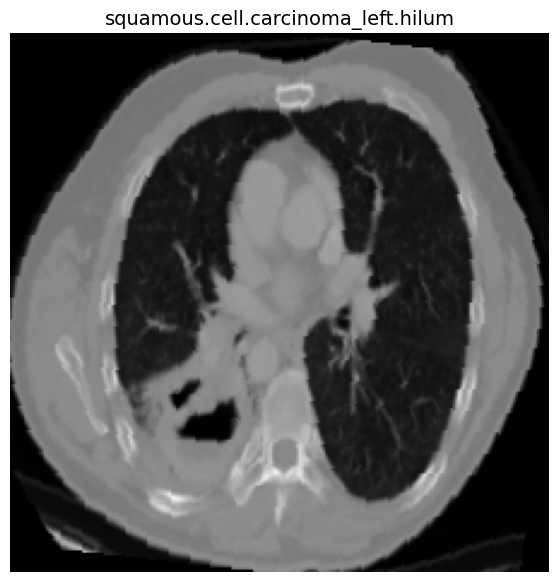

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

class Config:
    DATASET_ROOT = '/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data'

    CLASSES = [
        "adenocarcinoma", 
        "large.cell.carcinoma", 
        "normal", 
        "squamous.cell.carcinoma"
    ]
    
    CLASS_TO_IDX = {cls_name: idx for idx, cls_name in enumerate(CLASSES)}
    IDX_TO_CLASS = {idx: cls_name for idx, cls_name in enumerate(CLASSES)}
    NUM_CLASSES  = 4

    IMG_SIZE   = 224
    BATCH_SIZE = 64
    SEED       = 42
cfg = Config()

data_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
     transforms.RandomHorizontalFlip(p=0.7),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
 

]) 
train_data = datasets.ImageFolder(root="/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train",
                                  transform=data_transform, 
                                  target_transform=None) 

test_data = datasets.ImageFolder(root="/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/test",
                                 transform=data_transform)


validation_data = datasets.ImageFolder(root="/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/valid",
                                 transform=data_transform)
train_data, test_data ,validation_data
class_names = train_data.classes
class_names
class_dict = train_data.class_to_idx
class_dict
# Change the key
old_key1 = 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib'
new_key1 = 'adenocarcinoma_left.lower.lobe'

old_key2 = 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa'
new_key2 = 'large.cell.carcinoma_left.hilum'

old_key3 = 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'
new_key3 = 'squamous.cell.carcinoma_left.hilum'

# Step 1: Add new key-value pair
class_dict[new_key1] = class_dict[old_key1]
class_dict[new_key2] = class_dict[old_key2]
class_dict[new_key3] = class_dict[old_key3]


# Step 2: Remove old key-value pair
del class_dict[old_key1]
del class_dict[old_key2]
del class_dict[old_key3]


print(class_dict)
class_names[0]=new_key1
class_names[1]=new_key2
class_names[3]=new_key3
class_names
random_idx = torch.randint(0, len(train_data), size=(1,)).item()
img, label = train_data[random_idx][0], train_data[random_idx][1]

print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")
print(f"class name: {class_names[label]}")
import random 
from PIL import Image
import matplotlib.pyplot as plt
random_idx = torch.randint(0, len(train_data), size=(1,)).item()
img, label = train_data[random_idx][0], train_data[random_idx][1]


img_permute = img.permute(1, 2, 0)
print(f"Image permute: {img_permute.shape} ")
plt.figure(figsize=(12, 7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize=14)
BATCH_SIZE=32
train_loader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle=True)
val_loader = DataLoader(dataset=validation_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=False)
test_loader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=False)



✅ Section 2 imports ready
✅ CONFIG loaded
   Model  : DepthWiseMamba-Nano
   Epochs : 50
   Optim  : Adam  lr=0.0001
   Sched  : None
   W&B    : OFF
   GFLOPs : ON
🏗️  DepthWiseMamba-Nano | Params: 2,042,879 (2.04 M)
✅ DSMaT architecture defined

📐 GFLOPs ANALYSIS
  Forward  (inference) : 0.1533 GFLOPs
  Backward (≈ 2× fwd)  : 0.3066 GFLOPs
  Fwd+Bwd  (1 step)    : 0.4599 GFLOPs
  Per epoch (20 batches) : 9.20 GFLOPs
  Full training (50 ep)  : 459.88 GFLOPs
  Parameters           : 2.04 M
✅ Training utilities defined

🚀 Training DepthWiseMamba-Nano for 50 epochs ...
  Ep   1/50 | Tr 1.0940/0.4763 | Val 2.5822/0.2083 | 16.9s ★ saved
  Ep   2/50 | Tr 0.9274/0.5922 | Val 3.1074/0.2083 | 4.9s
  Ep   3/50 | Tr 0.8697/0.6020 | Val 1.9708/0.2083 | 4.7s
  Ep   4/50 | Tr 0.8452/0.5987 | Val 1.3370/0.4306 | 4.9s ★ saved
  Ep   5/50 | Tr 0.8432/0.6150 | Val 1.2191/0.4861 | 4.8s ★ saved
  Ep   6/50 | Tr 0.8050/0.6313 | Val 1.1789/0.4722 | 4.7s
  Ep   7/50 | Tr 0.7491/0.6639 | Val 1.1604/0.5000 | 

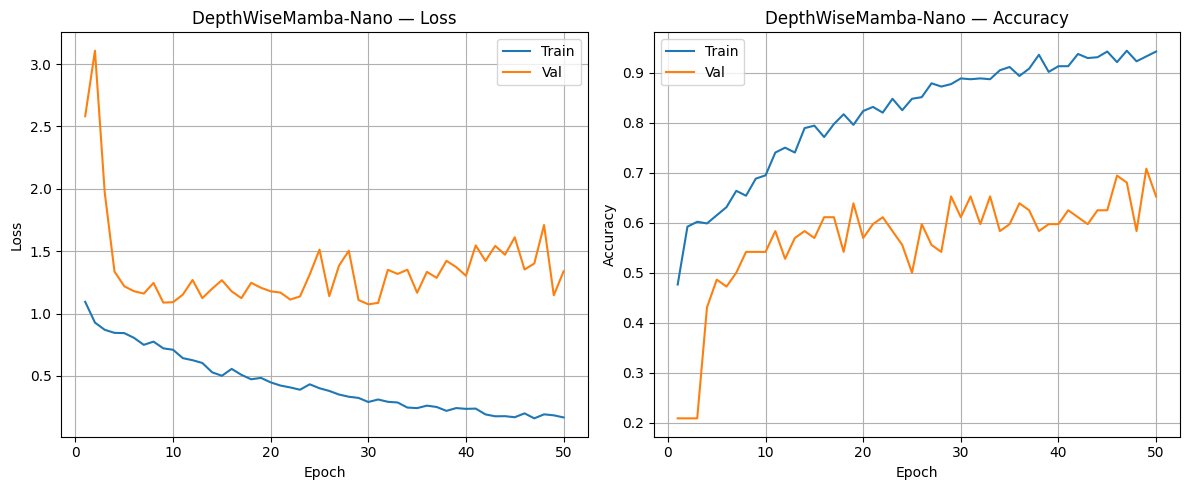

  TEST — DepthWiseMamba-Nano  |  Acc: 46.35%
                         precision    recall  f1-score   support

         adenocarcinoma       0.56      0.33      0.42       120
   large.cell.carcinoma       0.26      0.86      0.39        51
                 normal       0.91      0.96      0.94        54
squamous.cell.carcinoma       0.67      0.11      0.19        90

               accuracy                           0.46       315
              macro avg       0.60      0.57      0.49       315
           weighted avg       0.60      0.46      0.44       315



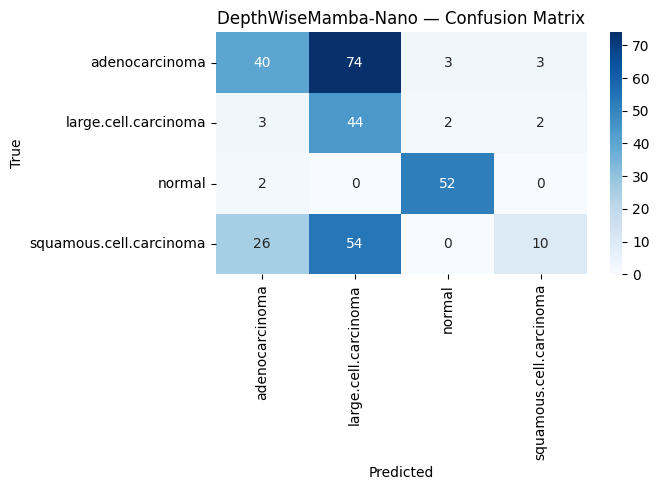

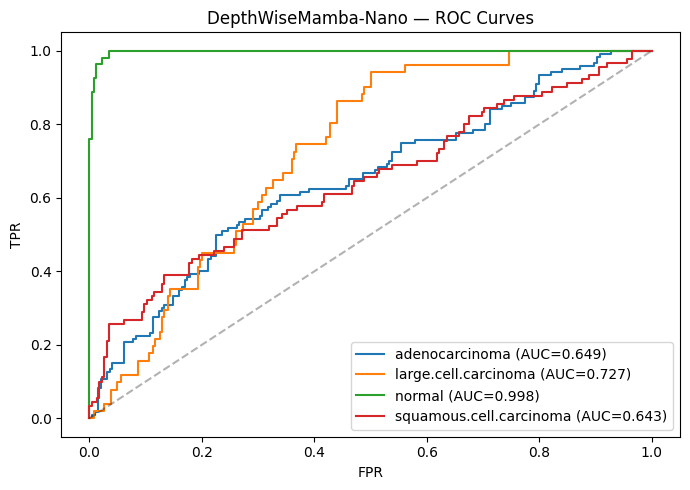


🏆 DepthWiseMamba-Nano | Test Acc: 46.35% | Saved: ./saved_models/DepthWiseMamba-Nano3_best.pth
✅ Done!


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 2 — CONFIG + MODELS + TRAINING + EVALUATION                       ║
# ║  Dataset: Chest CT-Scan Images (4 Classes, RGB)                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Dependencies ─────────────────────────────────────────────────────────────
# !pip install thop -q        # needed for GFLOPs
# !pip install wandb  -q

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, 
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize
import wandb

print("✅ Section 2 imports ready")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.1  UNIFIED EXPERIMENT CONFIG
# ═══════════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Data ──────────────────────────────────────────────────────────────────
    "batch_size":   cfg.BATCH_SIZE,
    "num_workers":  2,
    "num_classes":  cfg.NUM_CLASSES,

    # ── Model Selection ──────────────────────────────────────────────────────
    "model_name": "DepthWiseMamba-Nano",

    # ── Architecture Hyperparameters ─────────────────────────────────────────
    "model": {
        "DepthWiseMamba-Pico": {
            "stem_channels":  (16, 32),
            "stage_channels": (48, 96, 128, 192),
            "stage_depths":   (1, 1, 2, 2),
            "sa_heads":       (4, 4),
            "mlp_expand":     2,
            "dropout":        0.4,
        },
        "DepthWiseMamba-Nano": {
            "stem_channels":  (24, 48),
            "stage_channels": (64, 128, 192, 256),
            "stage_depths":   (1, 2, 2, 2),
            "sa_heads":       (4, 4),
            "mlp_expand":     3,
            "dropout":        0.4,
        },
    },

    # ── Training ─────────────────────────────────────────────────────────────
    "epochs":           50,
    "optimizer":        "Adam",   # "AdamW" | "Adam" | "SGD"
    "optimizer_params": {
        "lr":           1e-4,
        "weight_decay": 1e-6,
    },
    "scheduler":        None,     # "CosineAnnealingLR" | "StepLR" | "ReduceLROnPlateau" | None
    "scheduler_params": {},       # extra kwargs forwarded to the scheduler constructor
    "grad_clip_max_norm": 1.0,

    # ── GFLOPs Tracking ──────────────────────────────────────────────────────
    "track_flops": True,          # False to skip entirely

    # ── W&B ──────────────────────────────────────────────────────────────────
    "wandb_project": "DSMaT-ChestCT-4Class",
    "wandb_enabled": False,       # Set to True if you want to use Weights & Biases
}

print("✅ CONFIG loaded")
print(f"   Model  : {CONFIG['model_name']}")
print(f"   Epochs : {CONFIG['epochs']}")
print(f"   Optim  : {CONFIG['optimizer']}  lr={CONFIG['optimizer_params']['lr']}")
print(f"   Sched  : {CONFIG['scheduler']}")
print(f"   W&B    : {'ON' if CONFIG['wandb_enabled'] else 'OFF'}")
print(f"   GFLOPs : {'ON' if CONFIG['track_flops'] else 'OFF'}")


# ═══════════════════════════════════════════════════════════════════════════════
# 2.2  MODEL ARCHITECTURE — BUILDING BLOCKS
# ═══════════════════════════════════════════════════════════════════════════════

class DSConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size, stride, padding, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=bias)

    def forward(self, x):
        return self.pw(self.dw(x))

class DSConvStem(nn.Module):
    def __init__(self, in_ch=3, mid_ch=32, out_ch=64): # Changed in_ch=3 for RGB
        super().__init__()
        self.stem = nn.Sequential(
            DSConv2d(in_ch, mid_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(mid_ch), nn.GELU(),
            DSConv2d(mid_ch, out_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_ch), nn.GELU(),
        )

    def forward(self, x):
        return self.stem(x)

class DSConvResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            DSConv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels), nn.GELU(),
            DSConv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return self.block(x) + x

class DSConvDownsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.down = nn.Sequential(
            DSConv2d(in_ch, out_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
        )

    def forward(self, x):
        return self.down(x)


# ═══════════════════════════════════════════════════════════════════════════════
# 2.3  MODEL ARCHITECTURE — MAMBA / ATTENTION / MLP
# ═══════════════════════════════════════════════════════════════════════════════

class SelectiveScan(nn.Module):
    def __init__(self, d_inner, d_state=16):
        super().__init__()
        self.d_state  = d_state
        self.dt_rank  = max(1, d_inner // 16)
        self.x_proj   = nn.Linear(d_inner, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj  = nn.Linear(self.dt_rank, d_inner, bias=True)
        A = (torch.arange(1, d_state + 1, dtype=torch.float32)
                  .unsqueeze(0).expand(d_inner, -1))
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(d_inner))

    def forward(self, x):
        B_batch, D, L = x.shape
        x_seq  = x.transpose(1, 2)                          
        x_dbl  = self.x_proj(x_seq)
        dt_raw, B_p, C_p = x_dbl.split(
            [self.dt_rank, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_raw))               
        A  = -torch.exp(self.A_log)                          
        dA  = torch.exp(dt.unsqueeze(-1) * A)               
        dBx = dt.unsqueeze(-1) * B_p.unsqueeze(2)           
        h   = torch.zeros(B_batch, D, self.d_state, device=x.device, dtype=x.dtype)
        ys  = []
        for t in range(L):
            h = dA[:, t] * h + dBx[:, t] * x_seq[:, t, :, None]
            ys.append((h * C_p[:, t, None, :]).sum(-1))
        y = torch.stack(ys, dim=2)                           
        return y + self.D.unsqueeze(0).unsqueeze(-1) * x

class MambaVisionMixer(nn.Module):
    def __init__(self, dim, d_state=16, kernel_size=3):
        super().__init__()
        half = dim // 2
        self.proj_x   = nn.Linear(dim, half, bias=False)
        self.conv1d_x = nn.Conv1d(half, half, kernel_size, padding='same', groups=half)
        self.ssm      = SelectiveScan(half, d_state)
        self.proj_z   = nn.Linear(dim, half, bias=False)
        self.conv1d_z = nn.Conv1d(half, half, kernel_size, padding='same', groups=half)
        self.out_proj = nn.Linear(dim, dim)
        self.norm     = nn.LayerNorm(dim)

    def forward(self, x):
        residual = x
        x  = self.norm(x)
        x1 = F.silu(self.conv1d_x(self.proj_x(x).transpose(1, 2)))
        x1 = self.ssm(x1)
        x2 = F.silu(self.conv1d_z(self.proj_z(x).transpose(1, 2)))
        out = torch.cat([x1, x2], dim=1).transpose(1, 2)
        return self.out_proj(out) + residual

class SelfAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)

    def forward(self, x):
        n = self.norm(x)
        out, _ = self.attn(n, n, n)
        return out + x

class MLPBlock(nn.Module):
    def __init__(self, dim, expand=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * expand), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * expand, dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x) + x

class MambaVisionLayer(nn.Module):
    def __init__(self, dim, mixer_type='mamba', num_heads=4,
                 d_state=16, mlp_expand=4, dropout=0.1):
        super().__init__()
        if mixer_type == 'mamba':
            self.mixer = MambaVisionMixer(dim, d_state=d_state)
        else:
            self.mixer = SelfAttentionBlock(dim, num_heads=num_heads, dropout=dropout)
        self.mlp = MLPBlock(dim, expand=mlp_expand, dropout=dropout)

    def forward(self, x):
        return self.mlp(self.mixer(x))


# ═══════════════════════════════════════════════════════════════════════════════
# 2.4  MODEL ARCHITECTURE — DSMaT FULL MODEL
# ═══════════════════════════════════════════════════════════════════════════════

class DSMaT(nn.Module):
    def __init__(self, in_channels=3, stem_channels=(32, 64), # Changed in_channels=3
                 stage_channels=(96, 192, 256, 384),
                 stage_depths=(2, 2, 4, 4), sa_heads=(4, 8),
                 d_state=16, mlp_expand=4, num_classes=4, dropout=0.2):
        super().__init__()
        stem_mid, stem_out = stem_channels

        self.stem = DSConvStem(in_channels, stem_mid, stem_out)

        self.down1  = DSConvDownsample(stem_out, stage_channels[0])
        self.stage1 = nn.Sequential(*[DSConvResBlock(stage_channels[0])
                                      for _ in range(stage_depths[0])])

        self.down2  = DSConvDownsample(stage_channels[0], stage_channels[1])
        self.stage2 = nn.Sequential(*[DSConvResBlock(stage_channels[1])
                                      for _ in range(stage_depths[1])])

        self.down3  = DSConvDownsample(stage_channels[1], stage_channels[2])
        n3m, n3a = stage_depths[2] // 2, stage_depths[2] - stage_depths[2] // 2
        self.stage3 = nn.ModuleList(
            [MambaVisionLayer(stage_channels[2], 'mamba',
                              d_state=d_state, mlp_expand=mlp_expand, dropout=dropout)
             for _ in range(n3m)]
            + [MambaVisionLayer(stage_channels[2], 'attention',
                                num_heads=sa_heads[0], mlp_expand=mlp_expand, dropout=dropout)
               for _ in range(n3a)]
        )

        self.down4  = DSConvDownsample(stage_channels[2], stage_channels[3])
        n4m, n4a = stage_depths[3] // 2, stage_depths[3] - stage_depths[3] // 2
        self.stage4 = nn.ModuleList(
            [MambaVisionLayer(stage_channels[3], 'mamba',
                              d_state=d_state, mlp_expand=mlp_expand, dropout=dropout)
             for _ in range(n4m)]
            + [MambaVisionLayer(stage_channels[3], 'attention',
                                num_heads=sa_heads[1], mlp_expand=mlp_expand, dropout=dropout)
               for _ in range(n4a)]
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.LayerNorm(stage_channels[3]),
            nn.Dropout(dropout),
            nn.Linear(stage_channels[3], num_classes),
        )

    def _run_token_stage(self, x, stage_layers):
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # (B, H*W, C)
        for layer in stage_layers:
            x = layer(x)
        return x.transpose(1, 2).reshape(B, C, H, W)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(self.down1(x))
        x = self.stage2(self.down2(x))
        x = self._run_token_stage(self.down3(x), self.stage3)
        x = self._run_token_stage(self.down4(x), self.stage4)
        return self.head(self.pool(x).flatten(1))

# ── Instantiate from CONFIG ──────────────────────────────────────────────────

def build_model(config):
    name = config["model_name"]
    arch = config["model"][name]
    # Explicitly enforce 3 channels for RGB input
    return DSMaT(in_channels=3, num_classes=config["num_classes"], **arch).to(DEVICE)

model    = build_model(CONFIG)
n_params = sum(p.numel() for p in model.parameters())
print(f"🏗️  {CONFIG['model_name']} | Params: {n_params:,} ({n_params / 1e6:.2f} M)")
print("✅ DSMaT architecture defined")


# ═══════════════════════════════════════════════════════════════════════════════
# 2.5  GFLOPs COMPUTATION
# ═══════════════════════════════════════════════════════════════════════════════

def compute_gflops(model, config, train_loader_ref, input_size=None):
    try:
        from thop import profile
    except ImportError:
        print("⚠️  thop not installed.  Run:  !pip install thop -q")
        return None

    if input_size is None:
        # RGB CT: 3 channels (updated from 1)
        input_size = (1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE)

    model.eval()
    dummy = torch.randn(*input_size, device=DEVICE)

    with torch.no_grad():
        macs, _ = profile(model, inputs=(dummy,), verbose=False)

    forward_gflops  = macs * 2 / 1e9           
    backward_gflops = forward_gflops * 2.0     
    fwd_bwd_gflops  = forward_gflops + backward_gflops   

    num_batches      = len(train_loader_ref)
    epochs           = config.get("epochs", 1)
    per_epoch_gflops = fwd_bwd_gflops * num_batches
    total_gflops     = per_epoch_gflops * epochs

    info = {
        "forward_gflops":    round(forward_gflops,    4),
        "backward_gflops":   round(backward_gflops,   4),
        "fwd_bwd_gflops":    round(fwd_bwd_gflops,    4),
        "per_epoch_gflops":  round(per_epoch_gflops,  2),
        "total_gflops":      round(total_gflops,       2),
        "params_M":          round(n_params / 1e6,     2),
    }

    print("\n" + "=" * 60)
    print("📐 GFLOPs ANALYSIS")
    print("=" * 60)
    print(f"  Forward  (inference) : {info['forward_gflops']:.4f} GFLOPs")
    print(f"  Backward (≈ 2× fwd)  : {info['backward_gflops']:.4f} GFLOPs")
    print(f"  Fwd+Bwd  (1 step)    : {info['fwd_bwd_gflops']:.4f} GFLOPs")
    print(f"  Per epoch ({num_batches} batches) : {info['per_epoch_gflops']:.2f} GFLOPs")
    print(f"  Full training ({epochs} ep)  : {info['total_gflops']:.2f} GFLOPs")
    print(f"  Parameters           : {info['params_M']:.2f} M")
    print("=" * 60)

    model.train()
    return info

flops_info = None
if CONFIG.get("track_flops", False):
    flops_info = compute_gflops(model, CONFIG, train_loader)
else:
    print("ℹ️  GFLOPs tracking disabled")


# ═══════════════════════════════════════════════════════════════════════════════
# 2.6  TRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════════════════════

def _build_optimizer(model, config):
    name, p = config["optimizer"], config["optimizer_params"]
    if name == "AdamW":
        return optim.AdamW(model.parameters(), **p)
    elif name == "Adam":
        return optim.Adam(model.parameters(), **p)
    elif name == "SGD":
        return optim.SGD(model.parameters(),
                         momentum=p.get("momentum", 0.9),
                         lr=p["lr"],
                         weight_decay=p.get("weight_decay", 0))
    raise ValueError(f"Unknown optimizer: {name}")

def _build_scheduler(optimizer, config):
    name  = config["scheduler"]
    extra = config.get("scheduler_params", {})
    if name is None or name == "None":
        return None
    if name == "CosineAnnealingLR":
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config["epochs"], **extra)
    elif name == "StepLR":
        return optim.lr_scheduler.StepLR(
            optimizer, step_size=extra.get("step_size", 10),
            gamma=extra.get("gamma", 0.1))
    elif name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min',
            patience=extra.get("patience", 5),
            factor=extra.get("factor", 0.5))
    raise ValueError(f"Unknown scheduler: {name}")

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, grad_clip):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        if grad_clip and grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        n = labels.size(0)
        loss_sum += loss.item() * n
        correct  += (outputs.argmax(1) == labels).sum().item()
        total    += n
    return loss_sum / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        probs   = F.softmax(outputs, dim=1)
        preds   = outputs.argmax(1)
        n = labels.size(0)
        loss_sum += loss.item() * n
        correct  += (preds == labels).sum().item()
        total    += n
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (loss_sum / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

def plot_history(history, model_name="Model"):
    if not history or not history.get("train_loss"):
        print("⚠️  No history to plot."); return None
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(epochs_range, history["train_loss"], label="Train")
    ax1.plot(epochs_range, history["val_loss"],   label="Val")
    ax1.set(title=f"{model_name} — Loss", xlabel="Epoch", ylabel="Loss")
    ax1.legend(); ax1.grid(True)
    ax2.plot(epochs_range, history["train_acc"], label="Train")
    ax2.plot(epochs_range, history["val_acc"],   label="Val")
    ax2.set(title=f"{model_name} — Accuracy", xlabel="Epoch", ylabel="Accuracy")
    ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()
    return fig

print("✅ Training utilities defined")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.7  W&B INIT + TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════

if CONFIG["wandb_enabled"]:
    from kaggle_secrets import UserSecretsClient
    wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    wandb.init(
        project=CONFIG["wandb_project"],
        name=CONFIG["model_name"],
        config=CONFIG,
    )
    print("✅ W&B run initialised")

criterion    = nn.CrossEntropyLoss()
optimizer    = _build_optimizer(model, CONFIG)
scheduler    = _build_scheduler(optimizer, CONFIG)
scaler       = GradScaler()

history      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
model_name   = CONFIG["model_name"]
save_path    = os.path.join(SAVE_DIR, f"{model_name}3_best.pth")

FORCE_RETRAIN = False   

if os.path.exists(save_path) and not FORCE_RETRAIN:
    print(f"\n✅ Checkpoint found: {save_path}")
    ckpt = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    if "scaler_state_dict" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    history      = ckpt.get("history", {})
    best_val_acc = ckpt.get("val_acc", 0.0)
    print(f"   Best Val Acc: {best_val_acc * 100:.2f}%  (Epoch {ckpt.get('epoch', '?')})")
    plot_history(history, model_name)

else:
    print(f"\n🚀 Training {model_name} for {CONFIG['epochs']} epochs ...")
    for epoch in range(CONFIG["epochs"]):
        t0 = time.time()

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion,
            scaler, DEVICE, CONFIG["grad_clip_max_norm"])

        val_loss, val_acc, *_ = evaluate(model, val_loader, criterion, DEVICE)

        if scheduler is not None:
            if CONFIG["scheduler"] == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if CONFIG["wandb_enabled"]:
            log_dict = {
                "epoch":      epoch + 1,
                "train_loss": tr_loss,  "train_acc": tr_acc,
                "val_loss":   val_loss, "val_acc":   val_acc,
                "lr":         optimizer.param_groups[0]["lr"],
            }
            if flops_info is not None:
                log_dict["cumulative_gflops"] = round(
                    flops_info["per_epoch_gflops"] * (epoch + 1), 2)
                log_dict["per_epoch_gflops"]  = flops_info["per_epoch_gflops"]
            wandb.log(log_dict)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "epoch":                epoch + 1,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scaler_state_dict":    scaler.state_dict(),
                "val_acc":              val_acc,
                "val_loss":             val_loss,
                "model_name":           model_name,
                "history":              history,
            }, save_path)
            star = " ★ saved"
        else:
            star = ""

        print(f"  Ep {epoch+1:3d}/{CONFIG['epochs']} | "
              f"Tr {tr_loss:.4f}/{tr_acc:.4f} | "
              f"Val {val_loss:.4f}/{val_acc:.4f} | "
              f"{time.time()-t0:.1f}s{star}")

    ckpt = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"\n  💾 Best model: Epoch {ckpt['epoch']} | Val Acc {ckpt['val_acc'] * 100:.2f}%")
    plot_history(history, model_name)


# ═══════════════════════════════════════════════════════════════════════════════
# 2.8  TEST-SET EVALUATION + W&B FINAL METRICS
# ═══════════════════════════════════════════════════════════════════════════════

test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE)

print("=" * 70)
print(f"  TEST — {model_name}  |  Acc: {test_acc * 100:.2f}%")
print("=" * 70)
print(classification_report(test_labels, test_preds, target_names=cfg.CLASSES))

fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cfg.CLASSES, yticklabels=cfg.CLASSES, ax=ax_cm)
ax_cm.set(title=f"{model_name} — Confusion Matrix", xlabel="Predicted", ylabel="True")
plt.tight_layout()
plt.savefig(f"confusion_matrix_{model_name}.png", dpi=150, bbox_inches="tight")
plt.show()

fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
y_bin = label_binarize(test_labels, classes=list(range(CONFIG["num_classes"])))
for cls_i in range(CONFIG["num_classes"]):
    fpr, tpr, _ = roc_curve(y_bin[:, cls_i], test_probs[:, cls_i])
    ax_roc.plot(fpr, tpr, label=f"{cfg.CLASSES[cls_i]} (AUC={auc(fpr, tpr):.3f})")
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax_roc.set(title=f"{model_name} — ROC Curves", xlabel="FPR", ylabel="TPR")
ax_roc.legend()
plt.tight_layout()
plt.savefig(f"roc_curves_{model_name}.png", dpi=150, bbox_inches="tight")
plt.show()

per_class_acc  = [accuracy_score(test_labels[test_labels == c],
                                  test_preds[test_labels == c])
                  for c in range(CONFIG["num_classes"])]
per_class_prec = precision_score(test_labels, test_preds, average=None)
per_class_rec  = recall_score(test_labels, test_preds, average=None)
per_class_f1   = f1_score(test_labels, test_preds, average=None)

if CONFIG["wandb_enabled"]:
    final_log = {
        "test_loss":     test_loss,
        "test_acc":      test_acc,
        "test_f1_macro": f1_score(test_labels, test_preds, average="macro"),
    }
    if flops_info is not None:
        final_log.update({
            "forward_gflops":     flops_info["forward_gflops"],
            "fwd_bwd_gflops":     flops_info["fwd_bwd_gflops"],
            "total_train_gflops": flops_info["total_gflops"],
            "params_M":           flops_info["params_M"],
        })
    wandb.log(final_log)
    wandb.log({"confusion_matrix": wandb.Image(fig_cm)})
    wandb.log({"roc_curves":       wandb.Image(fig_roc)})
    wandb.log({
        "per_class_metrics": wandb.Table(
            columns=["Class", "Accuracy", "Precision", "Recall", "F1"],
            data=[[cfg.CLASSES[c], per_class_acc[c], per_class_prec[c],
                   per_class_rec[c], per_class_f1[c]]
                  for c in range(CONFIG["num_classes"])],
        )
    })
    wandb.finish()
    print("\n✅ W&B run finished — all metrics and artifacts logged.")

print(f"\n🏆 {model_name} | Test Acc: {test_acc * 100:.2f}% | Saved: {save_path}")
print("✅ Done!")